### Algoritmo DBSCAN de clustering

#### Utilizamos primero el comando DBSCAN del paquete sklearn.cluster


In [1]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

# Para clustering
from sklearn.datasets import make_blobs
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN


In [2]:
# Tomamos nubes aleatorias y graficamos los puntos.
X, v = make_blobs(n_samples=60, centers=4, cluster_std=0.60, random_state=0)
datos = pd.DataFrame(X)
datos.columns = ["x", "y"]
datos.head()

,x,y
0,-0.555524,4.695958
1,2.161723,0.656595
2,-0.679905,7.742454
3,-0.633953,4.055416
4,-1.409058,8.316934


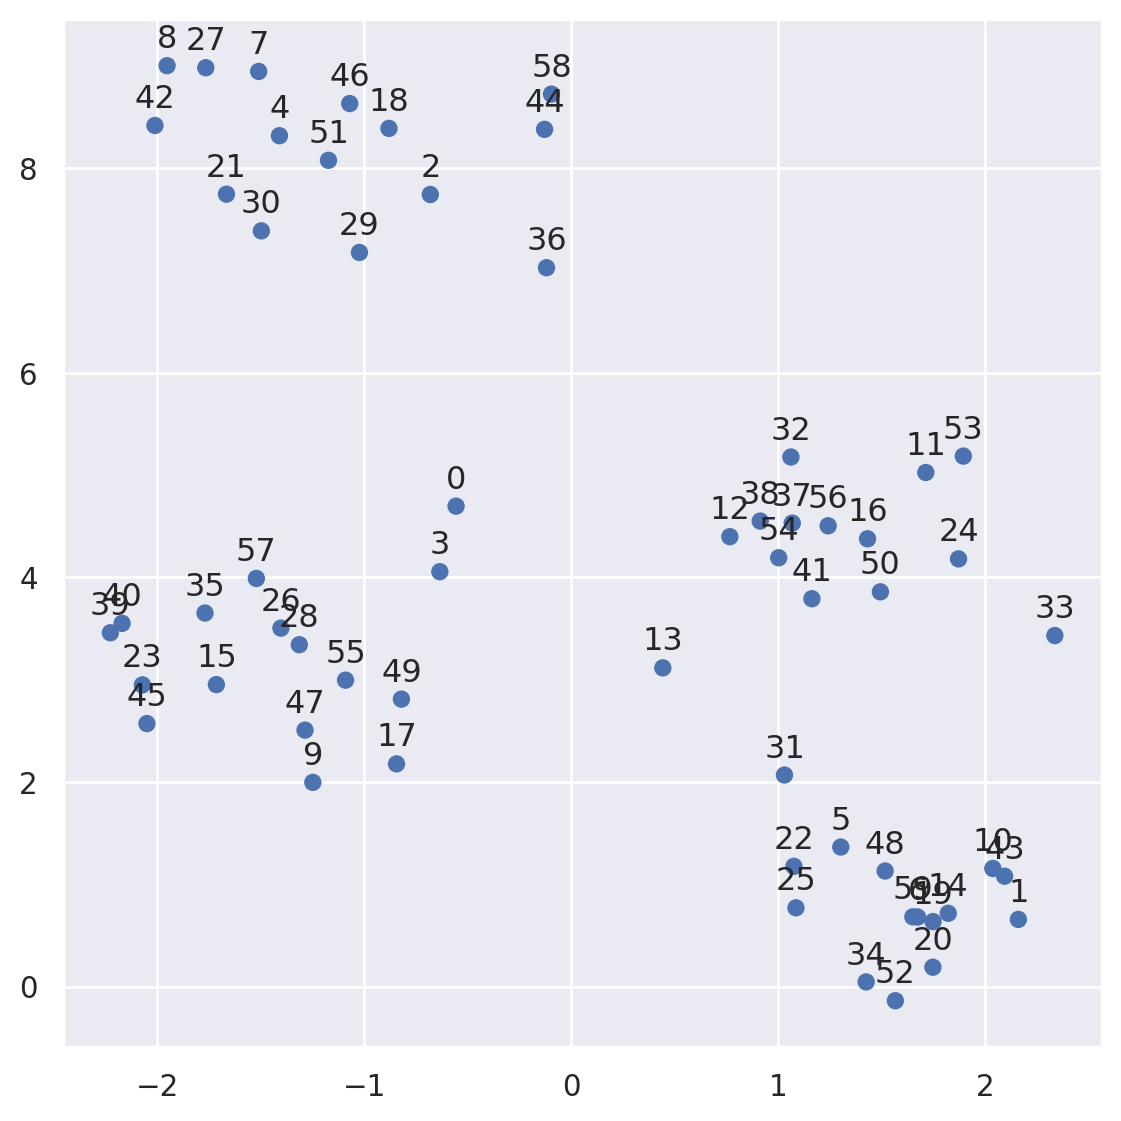

In [18]:
# El método Text nos permite incorporar texto a los nodos, es otro canal que podemos usar para codificar información.
# Podemos usarla para el número de nodo o para identificar el cluster.

(
    so.Plot(x = X[:,0], y = X[:,1], text = datos.index)
    .add(so.Dot())
    .add(so.Text(valign="bottom"))
    # .limit(x=(-5, 6), y=(-1, 10))
    .layout(size=(6, 6))  # Conviene graficar en un cuadrado para ver correctamente las distancias
)

In [34]:
# Elegimos eps mas chico que la distancia que vemos entre clusters.
# Elegimos min_samples según la densidad de puntos (¿cuántos puntos tienen a distancia menor que eps los puntos del cluster?)
clustering = DBSCAN(eps=0.8, min_samples=3)
etiqueta = clustering.fit_predict(X)
print(etiqueta)

[-1  0  1 -1  1  0  0  1  1  2  0  3  3 -1  0  2  3  2  1  0  0  1  0  2
  3  0  2  1  2  1  1  0  3 -1  0  2 -1  3  3  2  2  3  1  0  1  2  1  2
  0  2  3  1  0  3  3  2  3  2  1  0]


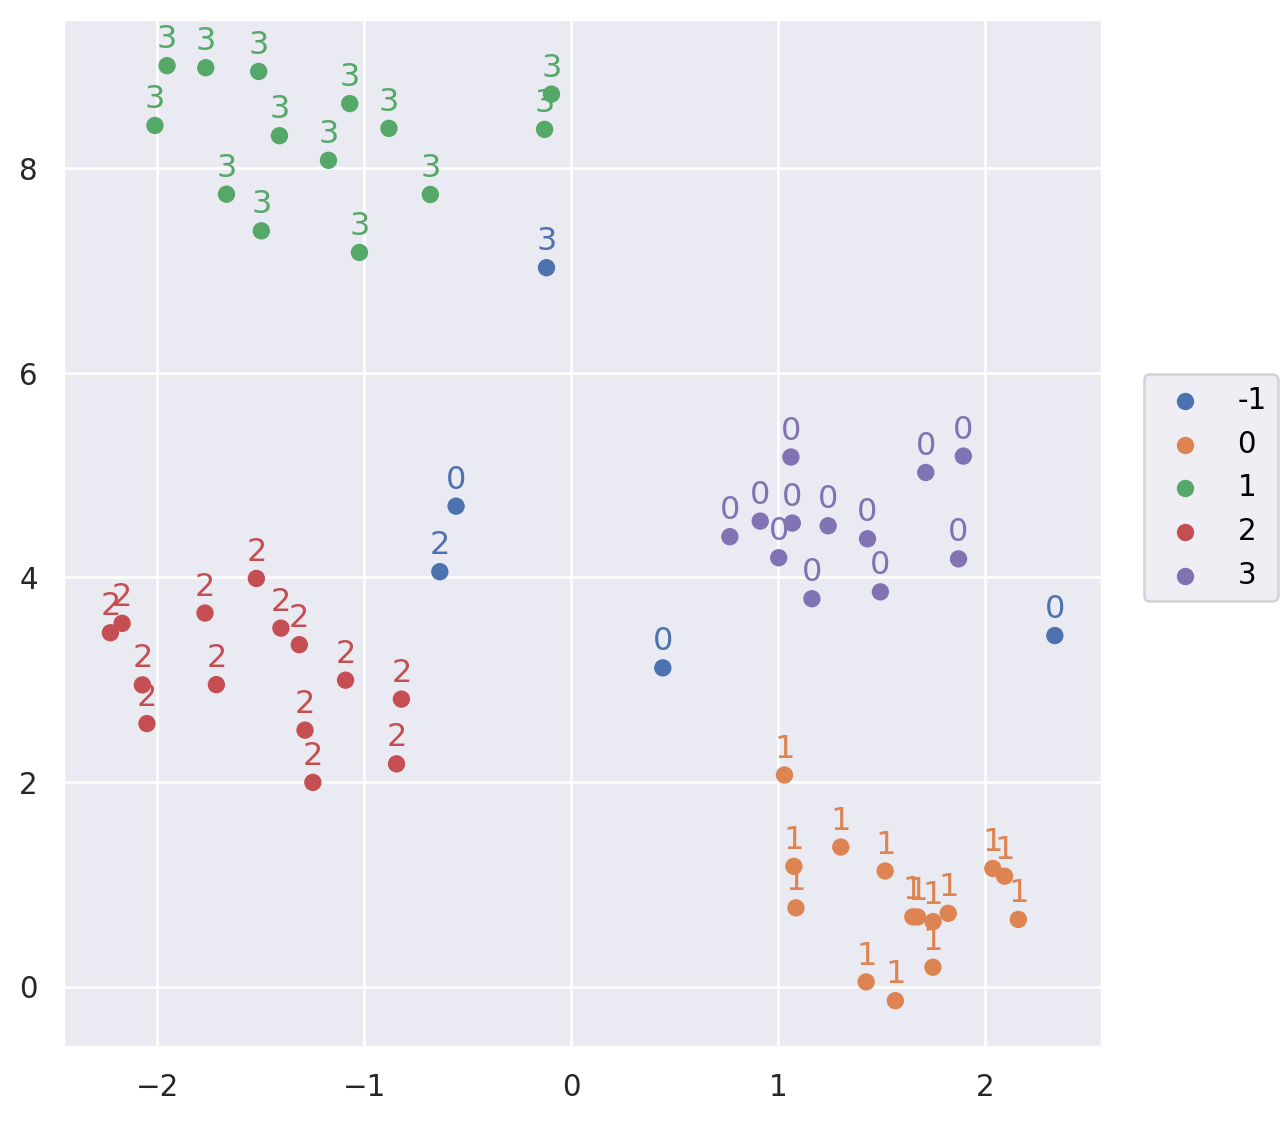

In [35]:
# Graficamos
(
    so.Plot(x = X[:,0], y = X[:,1], color = etiqueta.astype("str"), text = v.astype("str"))
    .add(so.Dot())
    .add(so.Text(valign="bottom"))
    .layout(size=(6,6))
)

En el último gráfico, ¿cuáles puntos fueron marcados como outliers? 

Fuera de los outliers, ¿quedó algún punto marcado incorrectamente?

Veamos ahora un ejemplo para el cual $k$-medias no resulta adecuado.

In [36]:
X, labels_true = make_circles(n_samples=1000, factor=0.5, noise=0.05, random_state = 42)
X = StandardScaler().fit_transform(X)

datos = pd.DataFrame(X)
datos.columns = ["x", "y"]
datos

,x,y
0,0.812184,0.302644
1,-0.783413,0.216127
2,-0.952174,0.331033
3,-0.538641,0.716837
4,0.799661,-1.592954
...,...,...
995,0.447599,1.652729
996,-1.764011,-0.511299
997,-0.127683,-0.944987
998,1.185388,-1.411580


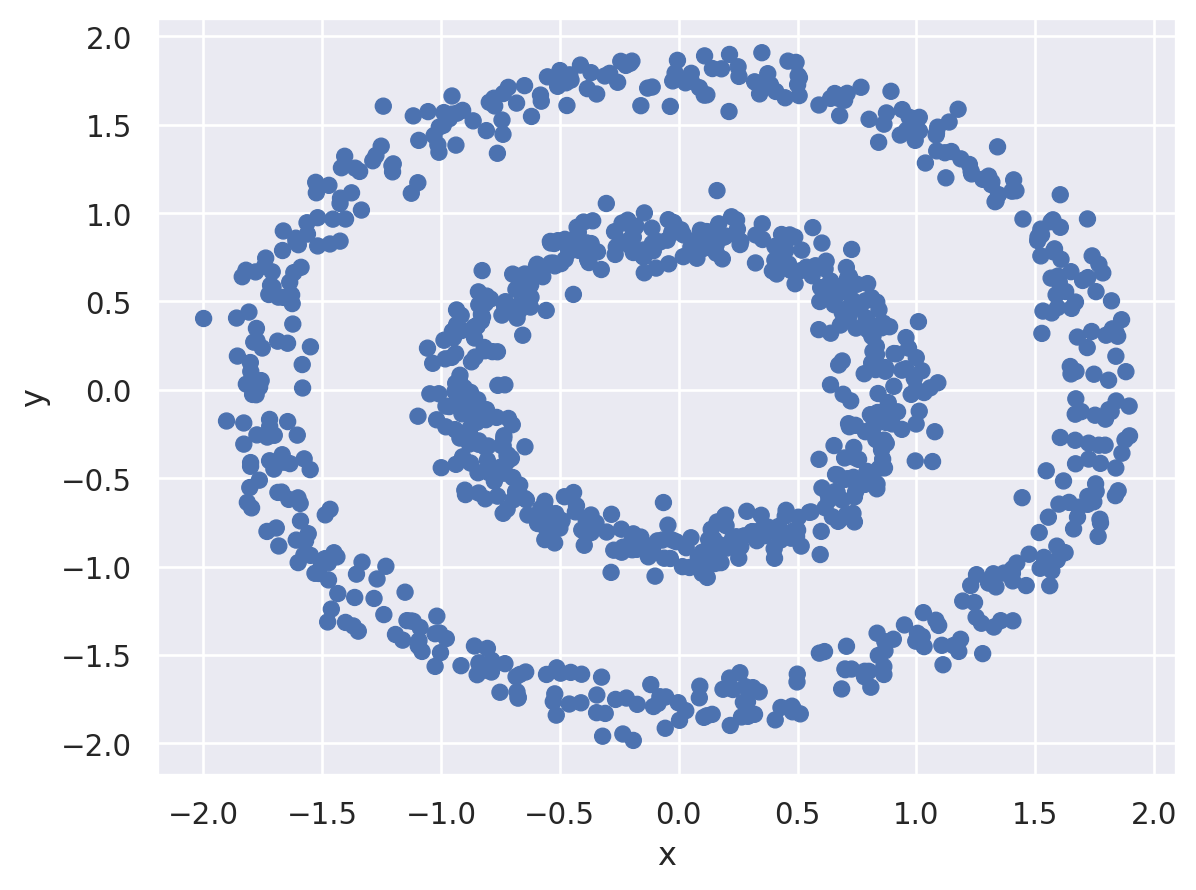

In [37]:
# Graficamos
(
    so.Plot(data = datos, x = "x", y = "y")
    .add(so.Dot())
)

Elegimos eps mas chico que la distancia que vemos entre clusters.

Elegimos min_samples según la densidad de puntos (¿cuántos puntos tienen a distancia menor que eps los puntos del cluster?)

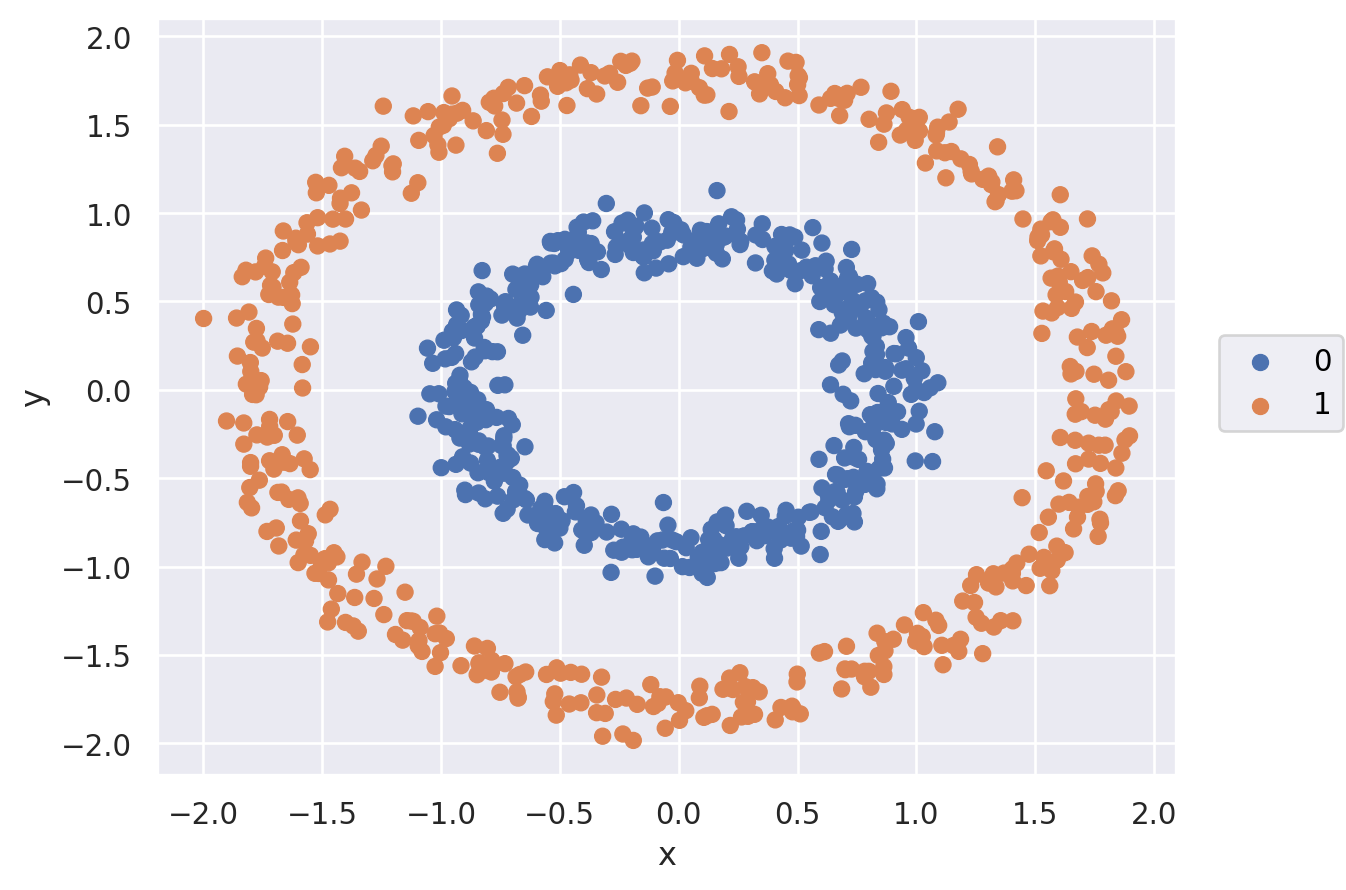

In [38]:

clustering = DBSCAN(eps=0.2, min_samples=3)
etiqueta = clustering.fit_predict(datos)

# Graficamos
(
    so.Plot(data = datos, x = "x", y = "y", color = etiqueta.astype("str"))
    .add(so.Dot())
)

Repetir para el siguiente ejemplo.

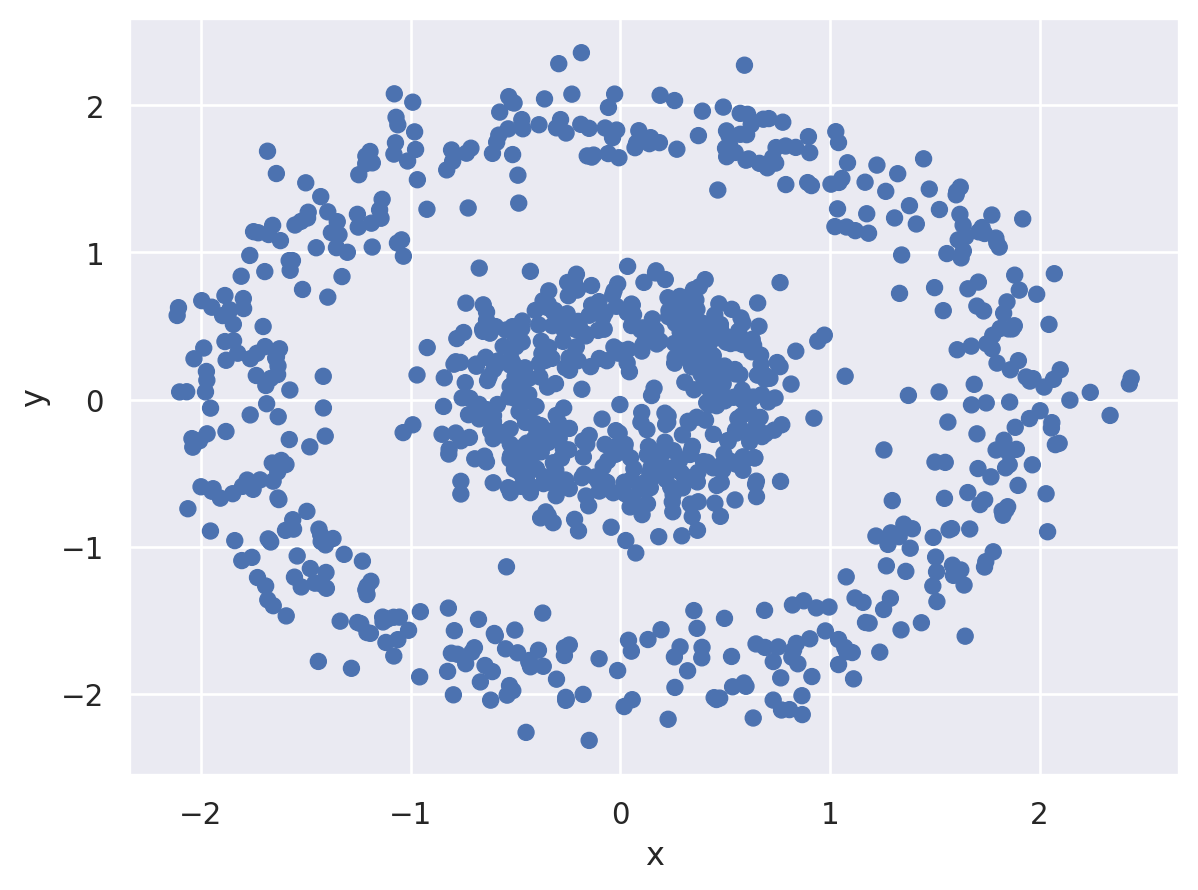

In [39]:
X, labels_true = make_circles(n_samples=1000, factor=0.3, noise=0.1, random_state = 5)
X = StandardScaler().fit_transform(X)   # Centramos los datos

datos = pd.DataFrame(X)
datos.columns = ["x", "y"]
datos

# Graficamos
(
    so.Plot(data = datos, x = "x", y = "y")
    .add(so.Dot())
)

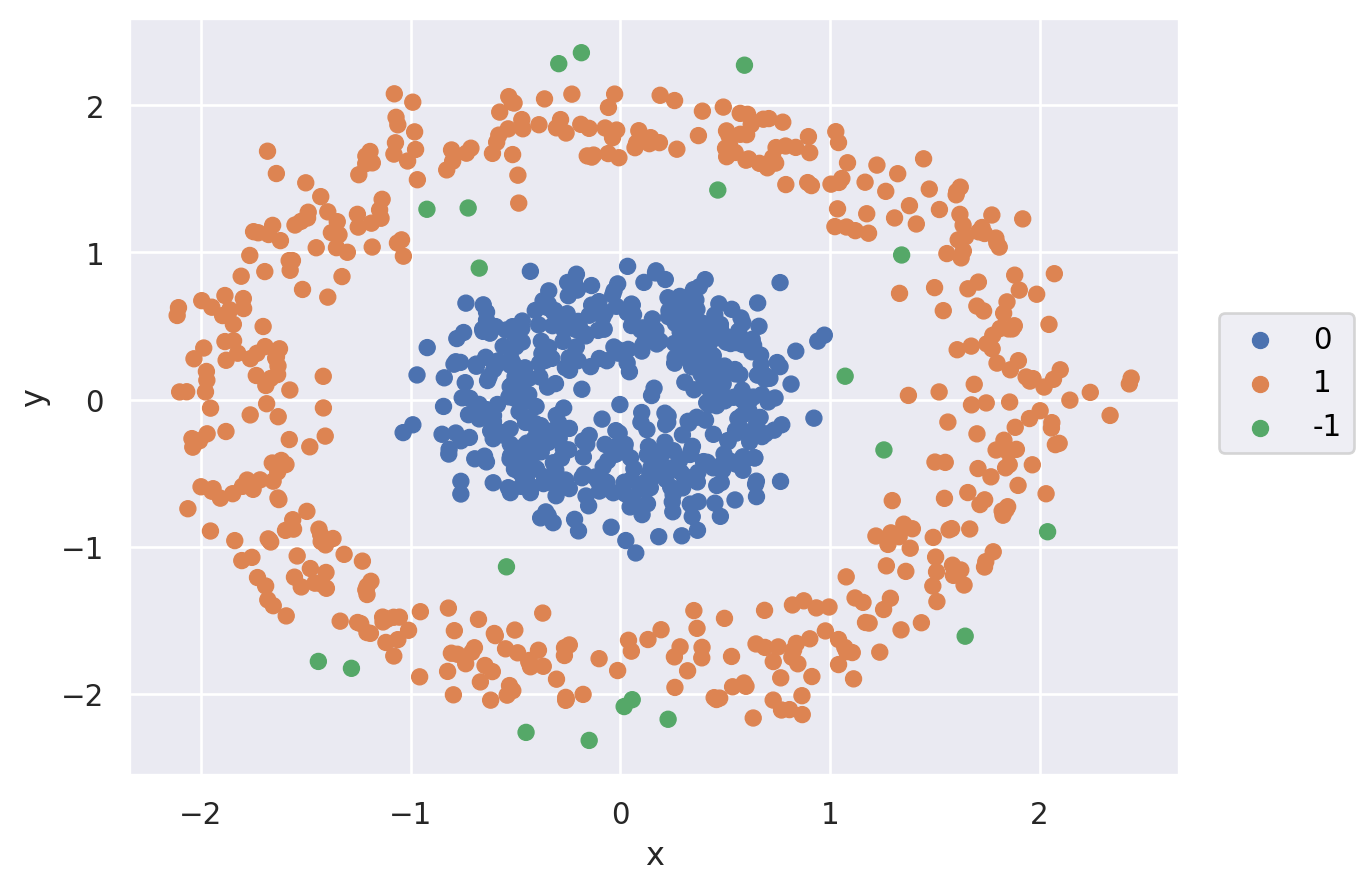

In [48]:
# Elegimos eps mas chico que la distancia que vemos entre clusters.
# Elegimos min_samples según la densidad de puntos (¿cuántos puntos tienen a distancia menor que eps los puntos del cluster?)
clustering = DBSCAN(eps=0.2, min_samples=3)
etiqueta = clustering.fit_predict(datos)

# Graficamos
(
    so.Plot(data = datos, x = "x", y = "y", color = etiqueta.astype("str"))
    .add(so.Dot())
)

## ¿Implementamos el algoritmo?


**Ejercicio 1**

1. Implementar una función que dado un conjunto de puntos (en un DataFrame), el índice de uno de los puntos y un radio eps, nos devuelva los índices de los puntos vecinos.
2. Aplicar la función al siguiente ejemplo para calcular los vecinos del punto 999.
3. Graficar todos los puntos, pintando de un color distinto los puntos hallados en el punto 2.

La salida de la función debe ser tipo "set" (conjunto), que permite fácilmente incorporar nuevos elementos al conjunto sin repetir.

### Tipo de datos set
Breve demostración

In [ ]:
A = {1, 2, 3, 5, 1, 4}
A

{1, 2, 3, 4, 5}

In [15]:
A.update({2,3,100})
A

{1, 2, 3, 4, 5, 100}

### Volvemos

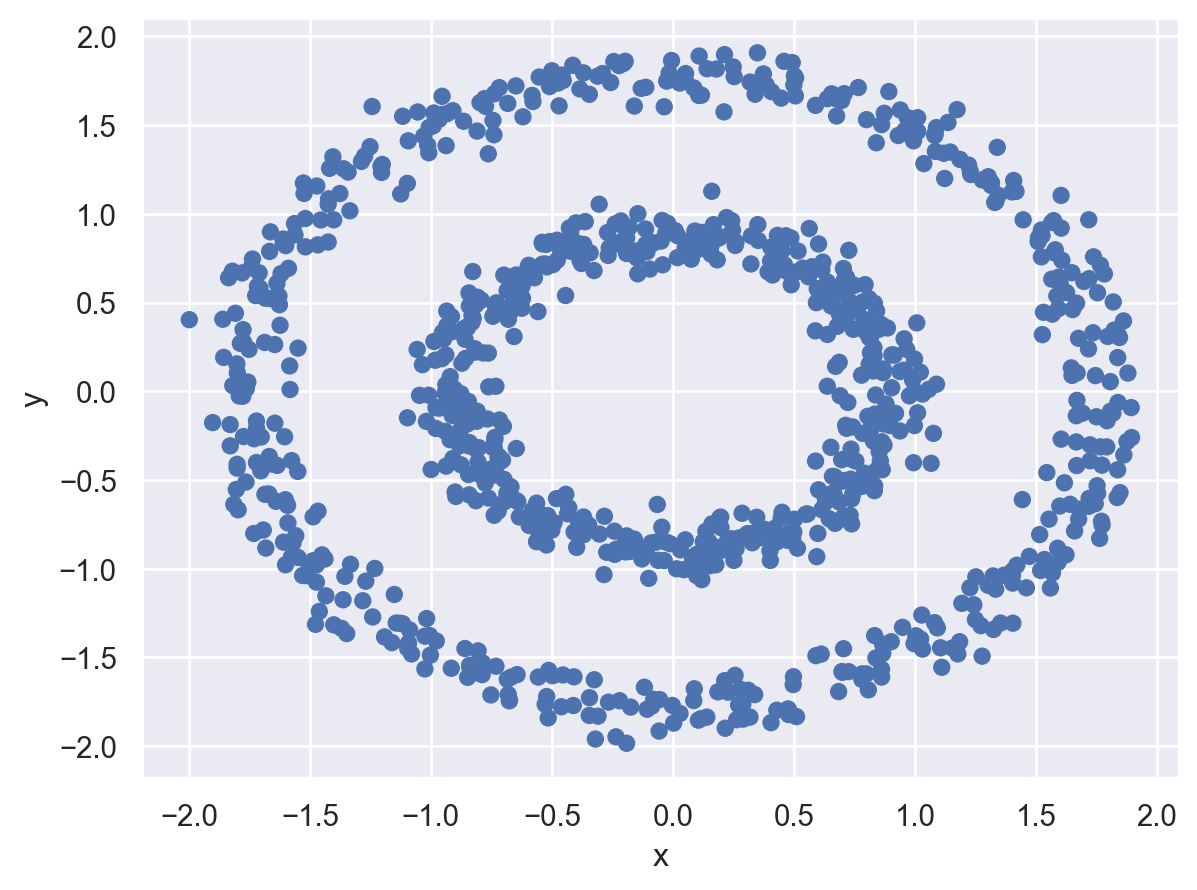

In [11]:
# Datos
X, labels_true = make_circles(n_samples=1000, factor=0.5, noise=0.05, random_state = 42)
X = StandardScaler().fit_transform(X)

datos = pd.DataFrame(X)
datos.columns = ["x", "y"]

# Graficamos
(
    so.Plot(data = datos, x = "x", y = "y")
    .add(so.Dot())
)

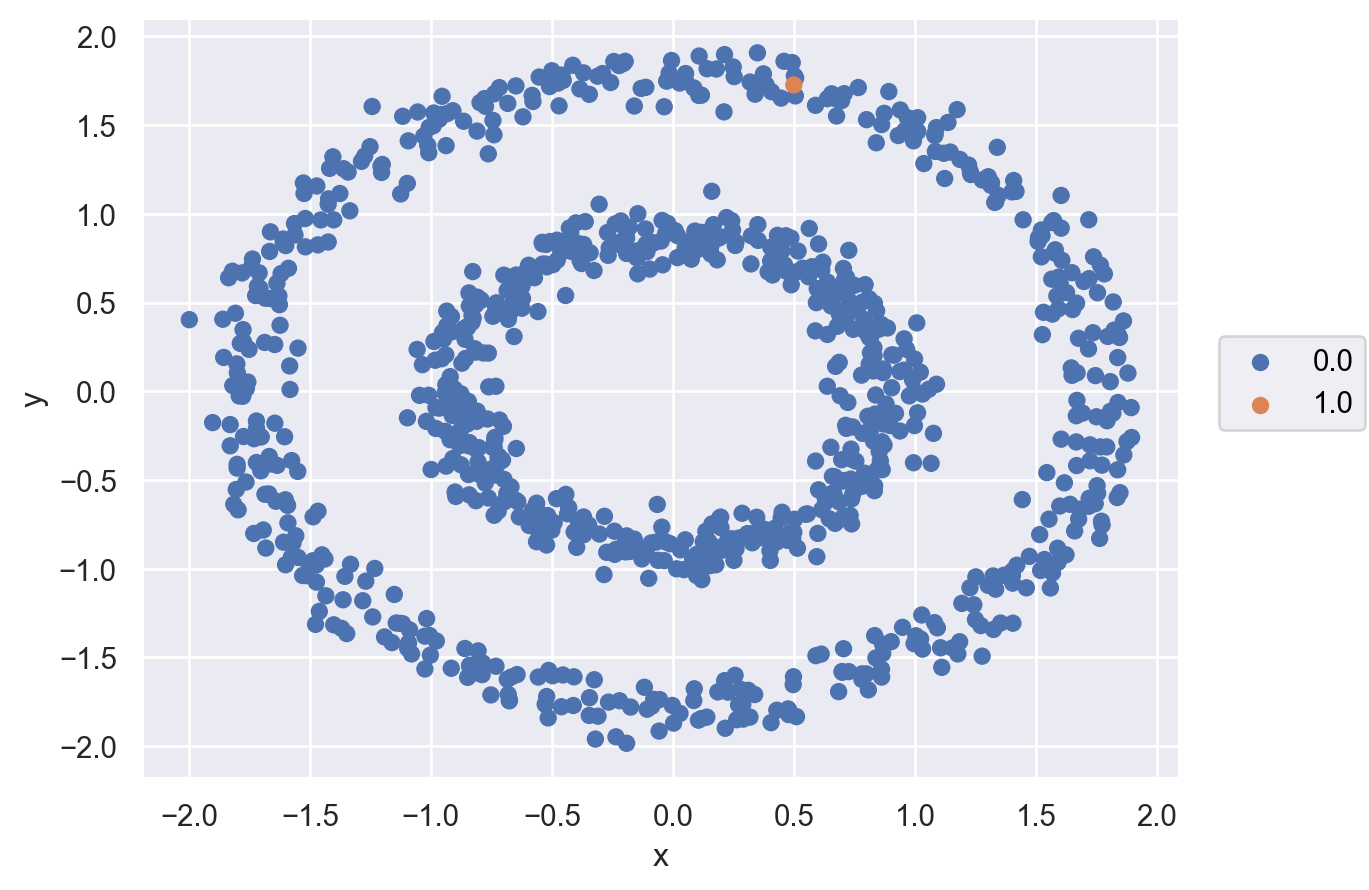

In [12]:
# Pintamos el punto 999
ind = 999
etiquetas = np.zeros(len(datos))
etiquetas[ind] = 1

(
    so.Plot(data = datos, x = "x", y = "y", color = etiquetas.astype("str"))
    .add(so.Dot())
)

**Ejercicio 2**

1. Implementar una función que dado un conjunto de puntos (en un DataFrame), un vector de etiquetas correspondientes a clusters y la etiqueta de algún cluster, agregue al cluster todos los puntos directamente alcanzables desde algún punto central del cluster.
2. Aplicar la función al ejemplo del ejercicio anterior.
3. Graficar todos los puntos, pintando de un color distinto los puntos hallados en el punto 2.

Repetir los puntos 2 y 3 un par de veces y observar como crece el cluster. Qué faltaría para poder encontrar el cluster completo?

In [17]:
def extender_cluster(datos, etiquetas, cluster, eps, minPts):
    indices_cluster = ???
    for ind in indices_cluster:
        ???

    print("Puntos en el cluster: ", np.sum(etiquetas == cluster))
    return(etiquetas)            

SyntaxError: invalid syntax (2619783946.py, line 2)

In [18]:
# Pintamos el punto 999
ind = 999
etiquetas = np.zeros(len(datos))
etiquetas[ind] = 1

eps = 0.3
minPts = 5

In [19]:
etiquetas = extender_cluster(datos, etiquetas, etiquetas[ind], eps, minPts)
(
    so.Plot(datos, x = "x", y = "y", color = etiquetas.astype("str"))
    .add(so.Dot())
)

NameError: name 'extender_cluster' is not defined

**Ejercicio 3**
1. Realizar mediante un for 20 iteraciones del procedimiento anterior y graficar el cluster resultante.
2. Si la cantidad de iteraciones no alcanzó para calcular todo el cluster aumentar la cantidad de iteraciones.
3. Identificar algún punto que no esté en el cluster encontrado, calcular el cluster correspondiente y graficar.

In [ ]:
eps = 0.2
minPts = 5
ind = 999
etiquetas = np.zeros(len(datos))
etiquetas[ind] = 1

for i in range(20):
    etiquetas = extender_cluster(datos, etiquetas, 1, eps, minPts)
    
(
    so.Plot(datos, x = "x", y = "y", color = etiquetas.astype("str"))
    .add(so.Dot())
)

In [ ]:
# Ahora queremos construir el otro cluster
etiquetas[0] = 2

for i in range(40):
    etiquetas = extender_cluster(datos, etiquetas, 2, eps, minPts)
    
(
    so.Plot(datos, x = "x", y = "y", color = etiquetas.astype("str"))
    .add(so.Dot())
)

# Ejemplo: detección de centros de actividad urbana
Fuente: https://bitsandbricks.github.io/post/dbscan-machine-learning-para-detectar-centros-de-actividad-urbana/

La S del nombre DBSCAN se refiere a "SPATIAL", este algoritmo es especialmente útil para detectar clusters en información espacial o en el plano, por ejemplo barrios, comunidades, focos de tormentas, etc.

Vamos a utilizarlo para detectar focos gastronómicos en la ciudad de Mendoza (más particularmente, bares).


## Ejercicio:
1) Exploramos y creamos un dataset que contenga solo los bares.
2) Aplicar DBSCAN eligiendo los parámetros arbitrariamente para identificar la "zona de bares"

¿Qué significan eps y minPts en el contexto de estos datos?

In [49]:
data = pd.read_csv("https://bitsandbricks.github.io/data/mendoza_poi.csv")
data.head()

,nombre,tipo,categoria,lat,lng
0,Banco de la Nación Argentina,atm,banca,-32.899985,-68.842262
1,Hospital Central BANCO DE LA NACION ARGENTINA ...,atm,banca,-32.892059,-68.832881
2,Banelco,atm,banca,-32.894630,-68.840298
3,Banelco,atm,banca,-32.893645,-68.839958
4,Cajero Automatico Banelco,atm,banca,-32.892873,-68.839935


In [50]:
data.categoria.unique()

array(['banca', 'cultura', 'culto', 'educacion', 'entretenimiento',
       'espacios_verdes', 'gastronomia', 'gobierno_y_serv_publicos',
       'retail', 'servicios', 'salud', 'transporte'], dtype=object)

In [53]:
bares = data[(data["tipo"] == "bar") & (data["categoria"] == "gastronomia")]
bares.head()

,nombre,tipo,categoria,lat,lng
2246,Cachavacha Bar,bar,gastronomia,-32.905599,-68.800351
2247,GO bar,bar,gastronomia,-32.914203,-68.821620
2248,Barometroclub Godoy Cruz,bar,gastronomia,-32.941565,-68.847243
2249,What is Resto Bar,bar,gastronomia,-32.945495,-68.854171
2250,Hangar 52 Beer Garden,bar,gastronomia,-32.931867,-68.850053


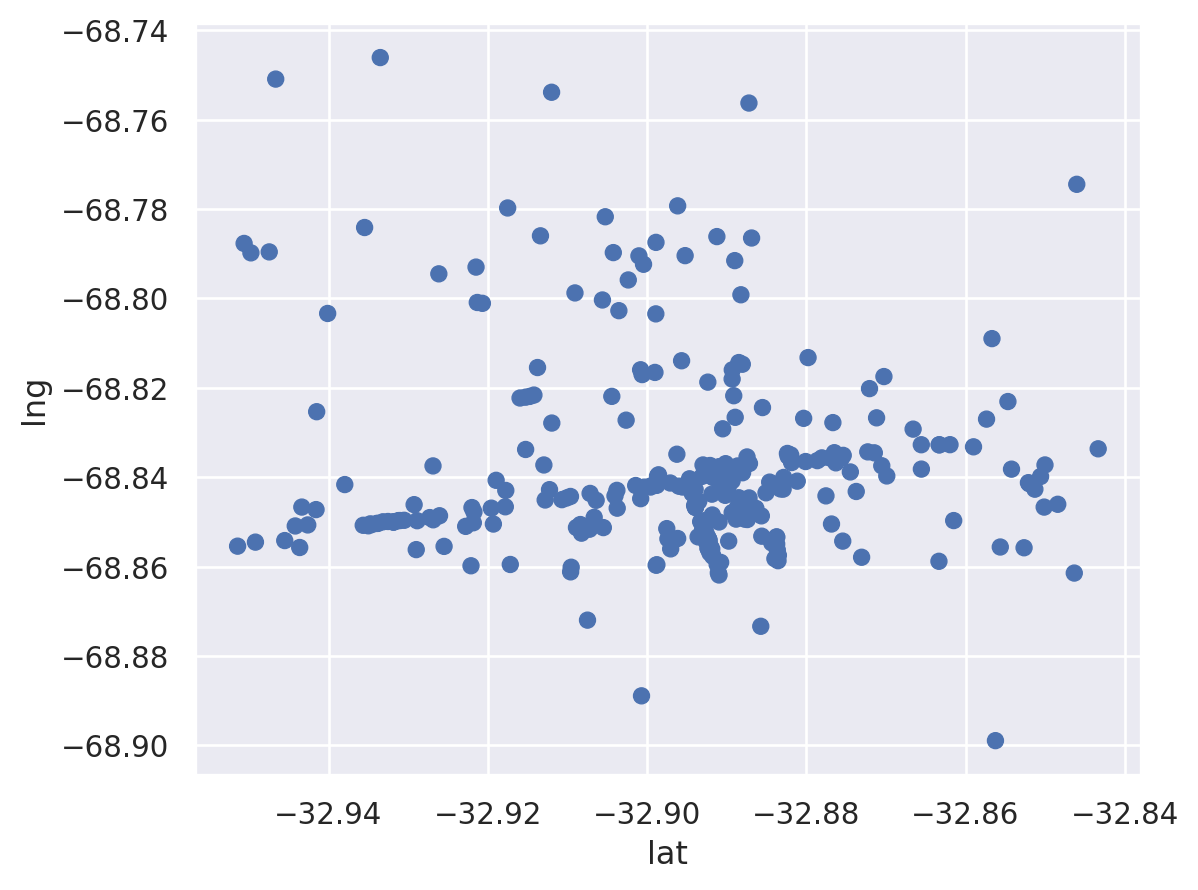

In [57]:
(
    so.Plot(bares, x="lat", y="lng")
    .add(so.Dot())
)

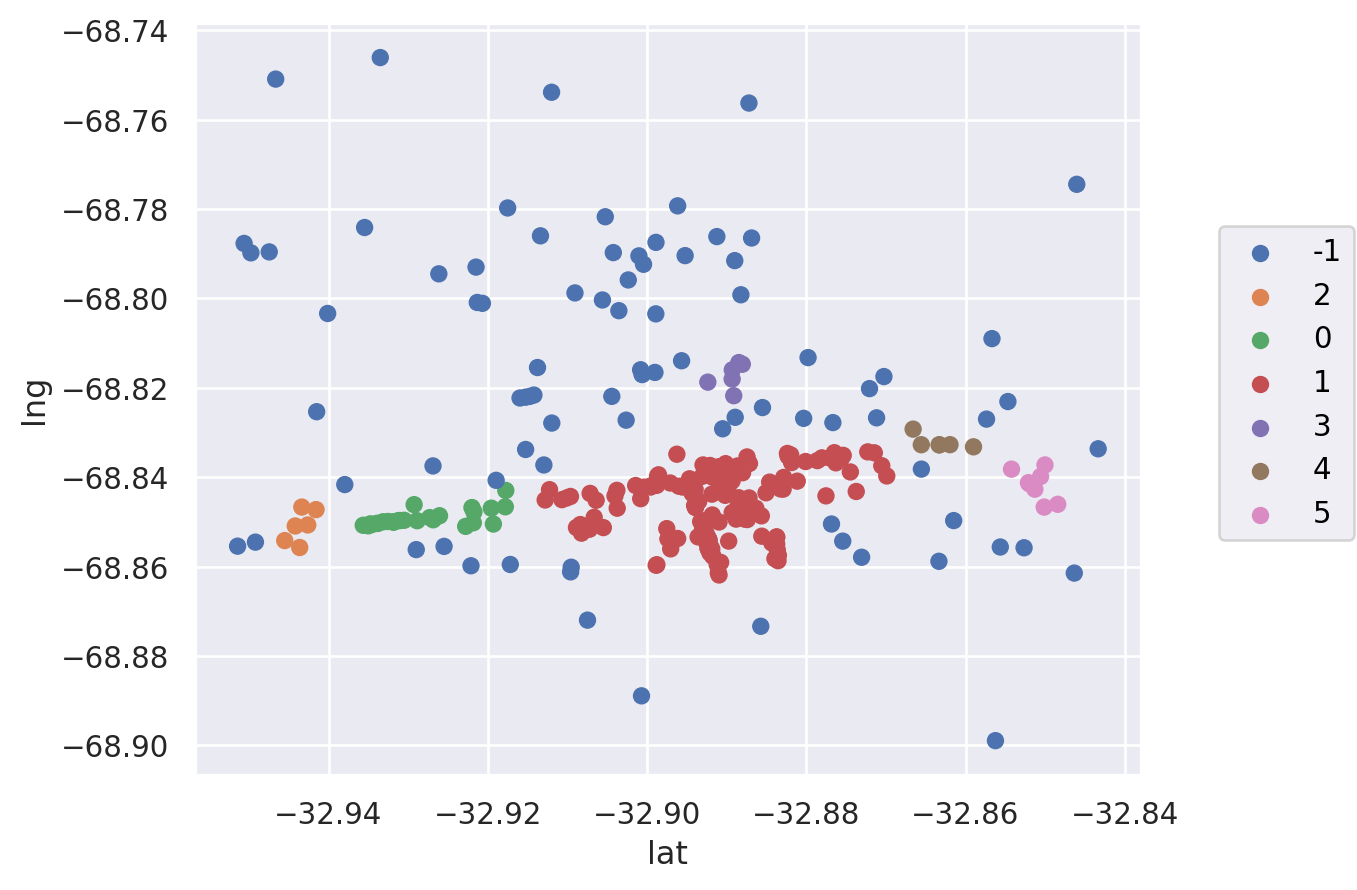

In [69]:
clustering = DBSCAN(eps=0.005, min_samples=6)
etiqueta = clustering.fit_predict(bares[["lat", "lng"]])

(
    so.Plot(data = bares, x = "lat", y = "lng", color = etiqueta.astype("str"))
    .add(so.Dot())
)

# Selección del hiperparámetro eps

Los valores eps y minPts son hiperparámetros, no se pueden aprender de los datos, pero algunas técnicas nos pueden ayudar.

¿Qué se te ocurre que podemos hacer?